# 5. Exploratory Data Analysis (EDA)

This section explores the statistical properties and relationships within the board game dataset.
The goal is to understand feature distributions, correlations, and how different attributes influence board game ratings.

The analysis includes:
- Distribution analysis
- Correlation analysis
- Feature impact exploration



# Importing Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

#Loading Dataset

In [2]:
input_df = pd.read_csv("data_cleaned_engineered_input.csv")
target_df = pd.read_csv("data_cleaned_engineered_target.csv")

In [5]:
#combining input and output

df = pd.concat([input_df, target_df], axis=1)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (4984, 155)


,min_players,max_players,avg_time,min_time,max_time,year,geek_rating,num_votes,age,owned,...,Word Game,World War I,World War II,Zombies,none.1,designer_avg_rating,designer_num_games,designer_total_votes,mechanic_popularity,avg_rating
0,1,4,120,60,120,2017,8.61858,15376,12,25928,...,0,0,0,0,0,8.190565,2,16648,482.222222,8.98893
1,2,4,60,60,60,2015,8.50163,26063,13,41605,...,0,0,0,0,0,8.563245,2,30244,609.285714,8.66140
2,2,4,240,180,240,2015,8.30183,12352,14,15848,...,0,0,0,0,0,7.171458,19,174603,467.333333,8.60673
3,1,5,120,120,120,2016,8.19914,26004,12,33340,...,0,0,0,0,0,7.482233,3,26563,842.800000,8.38461
4,2,2,180,120,180,2005,8.19787,31301,13,42952,...,0,0,0,0,0,8.339540,1,31301,804.000000,8.33954


## 5.1 Distribution Analysis

This section analyzes the distributions of important variables such as ratings,
game complexity, and playtime.

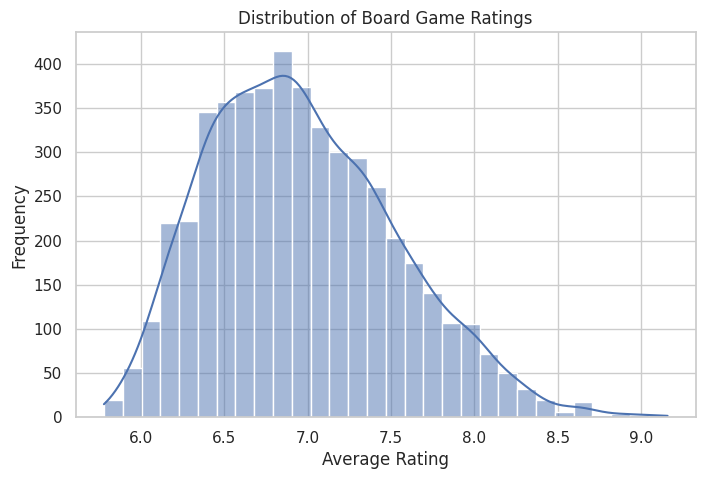

In [17]:
# Rating Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["avg_rating"], bins=30, kde=True)

plt.title("Distribution of Board Game Ratings")
plt.xlabel("Average Rating")
plt.ylabel("Frequency")

plt.show()

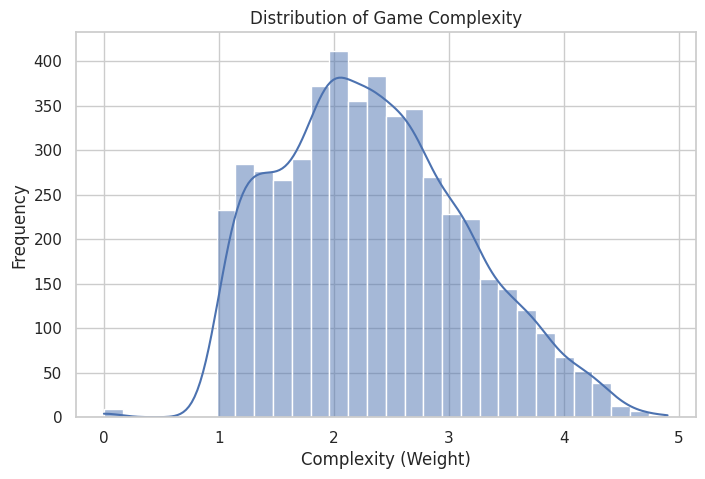

In [19]:
#Complexity Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["weight"], bins=30, kde=True)

plt.title("Distribution of Game Complexity")
plt.xlabel("Complexity (Weight)")
plt.ylabel("Frequency")

plt.show()

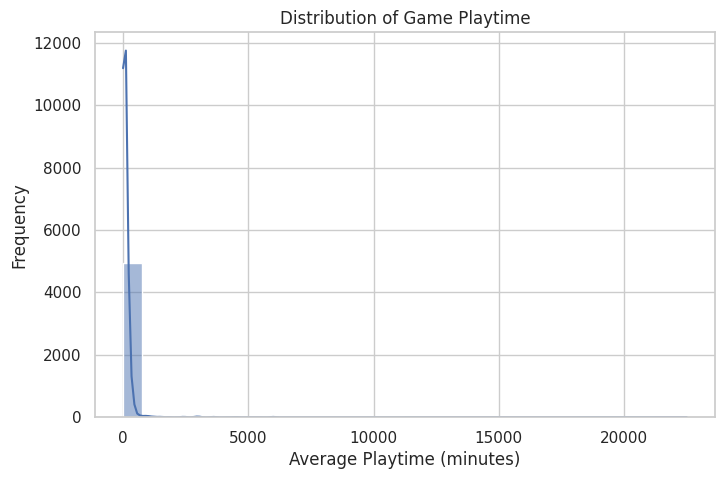

In [20]:
#Playtime Distribution

plt.figure(figsize=(8,5))
sns.histplot(df["avg_time"], bins=30, kde=True)

plt.title("Distribution of Game Playtime")
plt.xlabel("Average Playtime (minutes)")
plt.ylabel("Frequency")

plt.show()

In [21]:
# Basic Statistical Insights

print("Mean Rating:", df["avg_rating"].mean())
print("Rating Variance:", df["avg_rating"].var())

Mean Rating: 6.968956701444623
Rating Variance: 0.3163153897334486


## 5.2 Correlation Analysis

This section examines relationships between key variables in the dataset.
The goal is to understand how factors such as complexity, playtime,
and player count influence board game ratings.

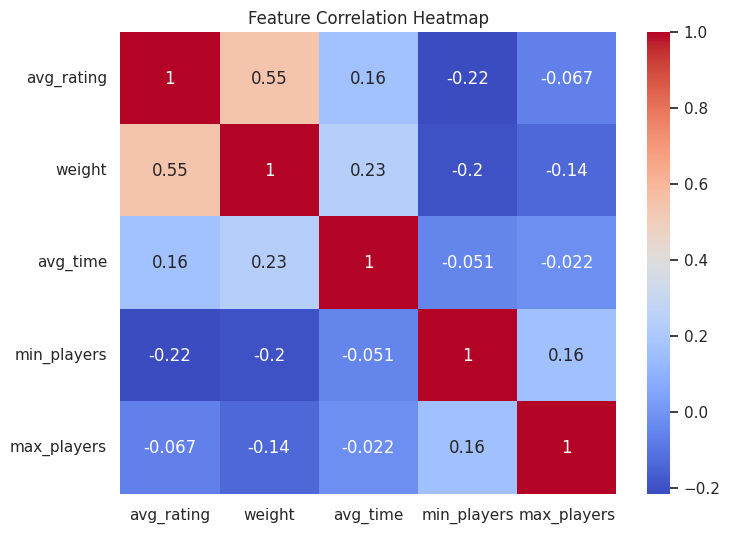

In [22]:
#Correlation Heatmap

corr_features = ["avg_rating", "weight", "avg_time", "min_players", "max_players"]

corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

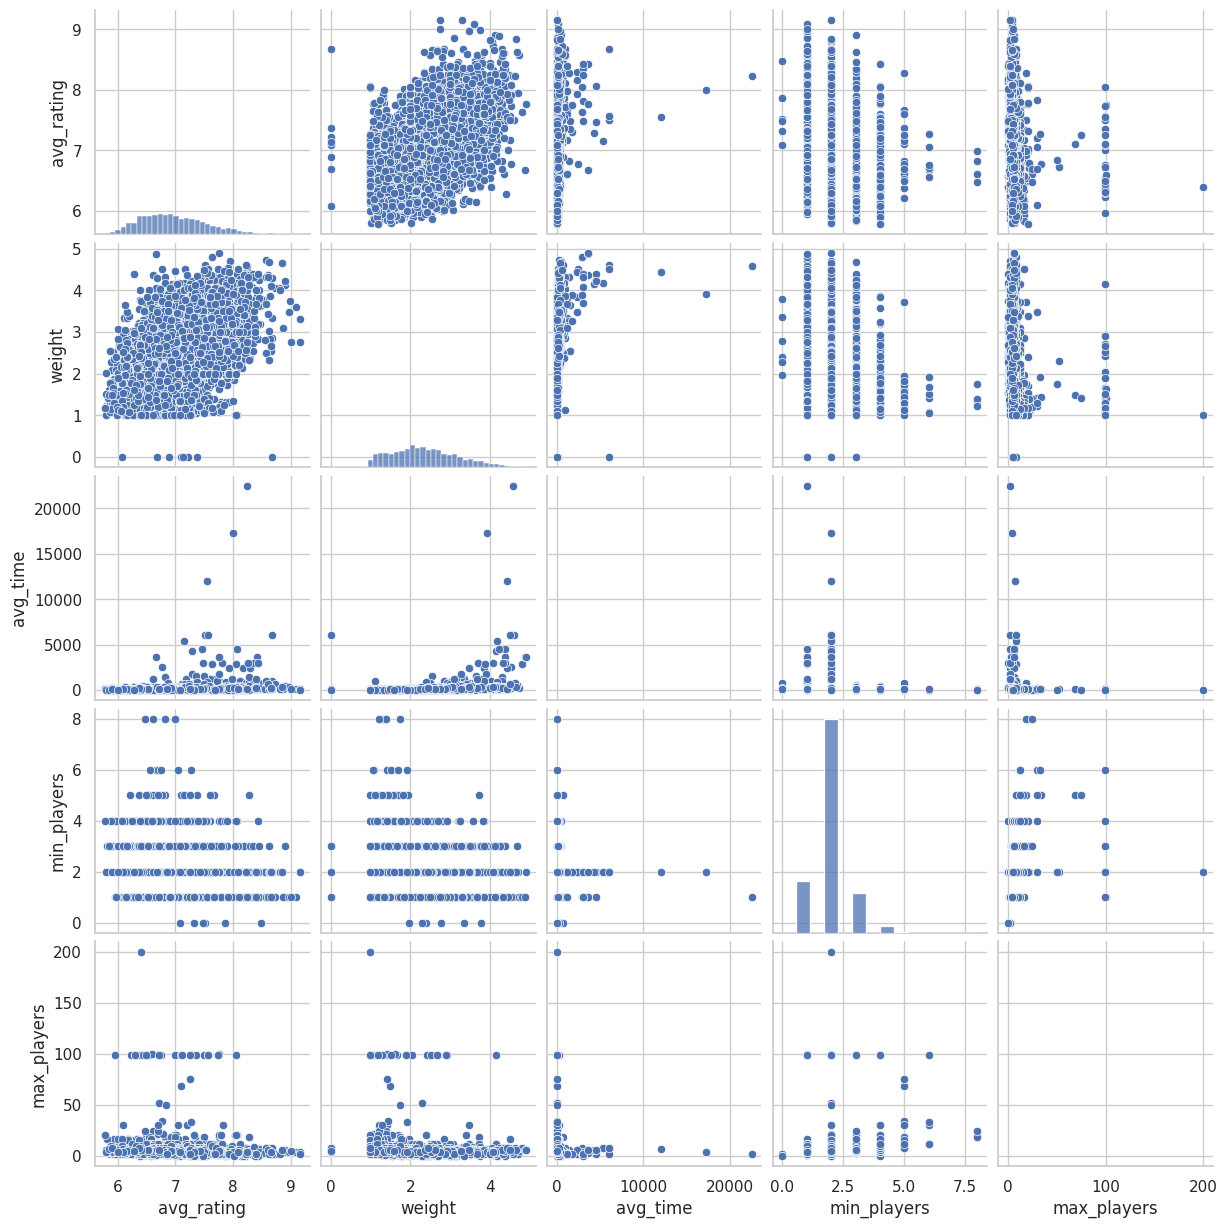

In [29]:
# Pairplot

sns.pairplot(df[corr_features])

plt.show()

## 5.3 Feature Impact Exploration

This section investigates how individual features influence board game ratings.
Scatter plots and box plots are used to visualize these relationships.

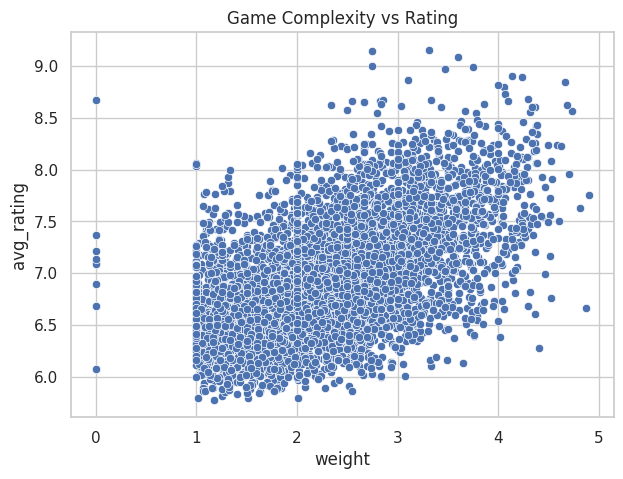

In [24]:
#Complexity vs Rating Scatter Plot

plt.figure(figsize=(7,5))
sns.scatterplot(x="weight", y="avg_rating", data=df)

plt.title("Game Complexity vs Rating")

plt.show()

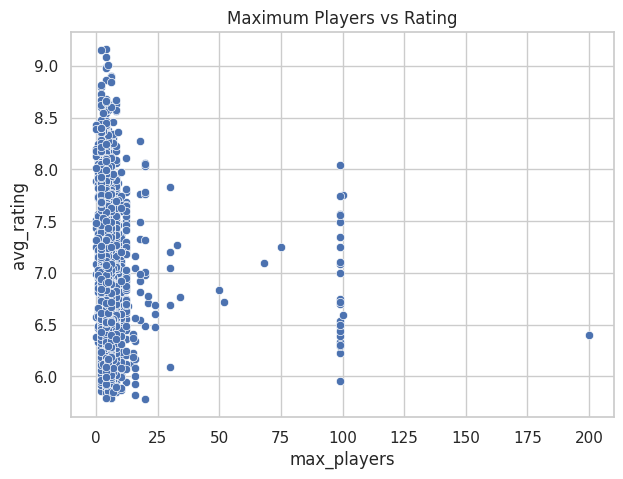

In [25]:
# Player Count vs Rating Scatter Plot

plt.figure(figsize=(7,5))
sns.scatterplot(x="max_players", y="avg_rating", data=df)

plt.title("Maximum Players vs Rating")

plt.show()

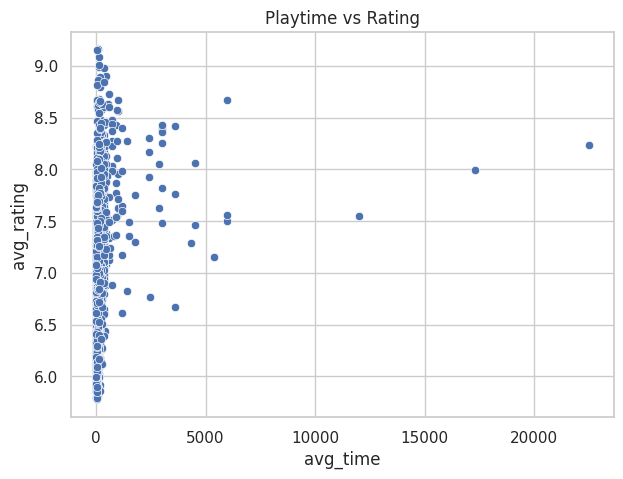

In [26]:
# Playtime vs Rating Scatter Plot

plt.figure(figsize=(7,5))
sns.scatterplot(x="avg_time", y="avg_rating", data=df)

plt.title("Playtime vs Rating")

plt.show()

/tmp/ipykernel_227/278358526.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


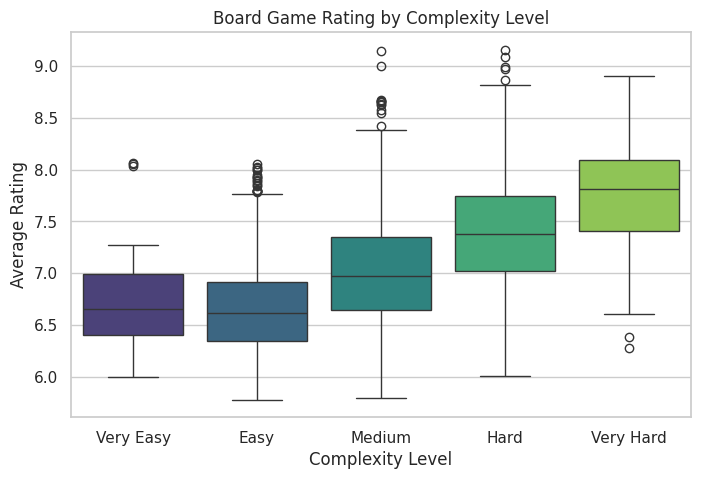

In [30]:
# Box Plot (Complexity Impact)

df["complexity_group"] = pd.cut(
    df["weight"],
    bins=[0,1,2,3,4,5],
    labels=["Very Easy","Easy","Medium","Hard","Very Hard"]
)

plt.figure(figsize=(8,5))

sns.boxplot(
    x="complexity_group",
    y="avg_rating",
    data=df,
    palette="viridis"
)

plt.title("Board Game Rating by Complexity Level")
plt.xlabel("Complexity Level")
plt.ylabel("Average Rating")

plt.show()